# Exploratory Data Analysis (EDA)

## Table of Contents
1. [Dataset Overview](#dataset-overview)
2. [Handling Missing Values](#handling-missing-values)
3. [Feature Distributions](#feature-distributions)
4. [Possible Biases](#possible-biases)
5. [Correlations](#correlations)


. [Correlations](#correlations)


In [81]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Dataset Overview

[Provide a high-level overview of the dataset. This should include the source of the dataset, the number of samples, the number of features, and example showing the structure of the dataset.]


In [82]:
# Load the data
train_x_df = pd.read_csv('../data/X_train.csv')
train_y_df = pd.read_csv('../data/Y_train.csv')

test_x_df = pd.read_csv('../data/X_test.csv')

C:\Users\tomhi\AppData\Local\Temp\ipykernel_22264\460957917.py:2: DtypeWarning: Columns (0: item21, 1: item22, 2: item23, 3: item24, 4: make21, 5: make22, 6: make23, 7: make24, 8: model21, 9: model22, 10: model23, 11: model24, 12: goods_code1, 13: goods_code8, 14: goods_code9, 15: goods_code10, 16: goods_code11, 17: goods_code12, 18: goods_code13, 19: goods_code14, 20: goods_code15, 21: goods_code16, 22: goods_code17, 23: goods_code18, 24: goods_code19, 25: goods_code20, 26: goods_code21, 27: goods_code22, 28: goods_code23, 29: goods_code24) have mixed types. Specify dtype option on import or set low_memory=False.
  train_x_df = pd.read_csv('../data/X_train.csv')
C:\Users\tomhi\AppData\Local\Temp\ipykernel_22264\460957917.py:5: DtypeWarning: Columns (0: item20, 1: item21, 2: item22, 3: item23, 4: item24, 5: make20, 6: make21, 7: make22, 8: make23, 9: make24, 10: model20, 11: model21, 12: model22, 13: model23, 14: model24, 15: goods_code1, 16: goods_code10, 17: goods_code11, 18: goods_c

### Train Data

In [83]:
# Number of samples
num_samples = train_x_df.shape[0]

# Number of features
num_features = train_x_df.shape[1]

# Display these dataset characteristics
print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}")

# Display the first few rows of the dataframe to show the structure
print("Example data:")
print(train_x_df.head())

Number of samples: 92790
Number of features: 146
Example data:
      ID                             item1                             item2  \
0  85517                         COMPUTERS                               NaN   
1  51113  COMPUTER PERIPHERALS ACCESSORIES                               NaN   
2  83008           TELEVISIONS HOME CINEMA                               NaN   
3  78712                         COMPUTERS  COMPUTER PERIPHERALS ACCESSORIES   
4  77846           TELEVISIONS HOME CINEMA                               NaN   

  item3 item4 item5 item6 item7 item8 item9  ... Nbr_of_prod_purchas16  \
0   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...                   NaN   
1   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...                   NaN   
2   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...                   NaN   
3   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...                   NaN   
4   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...                   NaN   

  Nbr_of_pr

### Test Data

In [84]:
# Number of samples
num_samples = test_x_df.shape[0]
# Number of features
num_features = test_x_df.shape[1]
# Display these dataset characteristics
print(f"Number of samples: {num_samples}")


Number of samples: 23198


## Handling Missing Values

[Identify any missing values in the dataset, and describe your approach to handle them if there are any. If there are no missing values simply indicate that there are none.]


In [85]:
# Check for missing values
missing_values = train_x_df.isnull().sum()
missing_values


ID                           0
item1                        0
item2                    48134
item3                    79889
item4                    88228
                         ...  
Nbr_of_prod_purchas21    92713
Nbr_of_prod_purchas22    92727
Nbr_of_prod_purchas23    92740
Nbr_of_prod_purchas24    92747
Nb_of_items                  0
Length: 146, dtype: int64

The null values are by design. According to the Challenge description:

> For each of these categories there are 24 instances that will either be filled with relevant information when an item exists in the basket, or null when it does not. For example, if an application has 3 items in the basket there will be information in the columns item1 to item3, cash_price1 to cash_price3, make1 to make3, model1 to model3, goods_code1 to goods_code3 and Nbr_of_prod_purchas1 to Nbr_of_prod_purchas3; but the remaining columns of these categories will be null (e.g. item4 to item24).

Observation: most samples seem to include 1-3 items.

In [86]:
# Handling missing values
# For now: leave them as NaN.
print(train_x_df.head())


      ID                             item1                             item2  \
0  85517                         COMPUTERS                               NaN   
1  51113  COMPUTER PERIPHERALS ACCESSORIES                               NaN   
2  83008           TELEVISIONS HOME CINEMA                               NaN   
3  78712                         COMPUTERS  COMPUTER PERIPHERALS ACCESSORIES   
4  77846           TELEVISIONS HOME CINEMA                               NaN   

  item3 item4 item5 item6 item7 item8 item9  ... Nbr_of_prod_purchas16  \
0   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...                   NaN   
1   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...                   NaN   
2   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...                   NaN   
3   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...                   NaN   
4   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...                   NaN   

  Nbr_of_prod_purchas17 Nbr_of_prod_purchas18 Nbr_of_prod_purchas19  \
0  

## Feature Distributions

[Plot the distribution of various features and target variables. Comment on the skewness, outliers, or any other observations.]


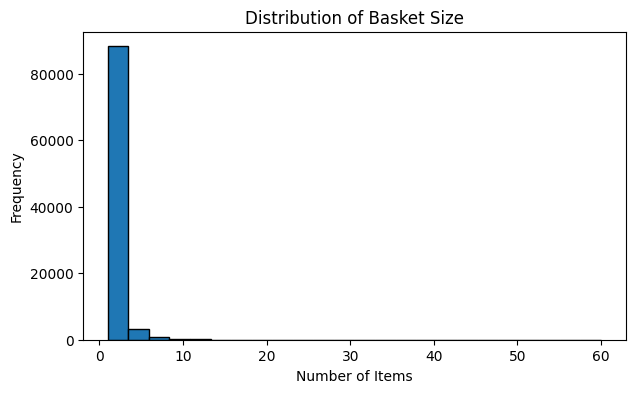

In [87]:
plt.figure(figsize=(7, 4))
plt.hist(train_x_df['Nb_of_items'].dropna(), bins=24, edgecolor='black')
plt.title('Distribution of Basket Size')
plt.xlabel('Number of Items')
plt.ylabel('Frequency')
plt.show()

**Observation:** As mentioned before, most baskets seem to have a low number of items (<10)

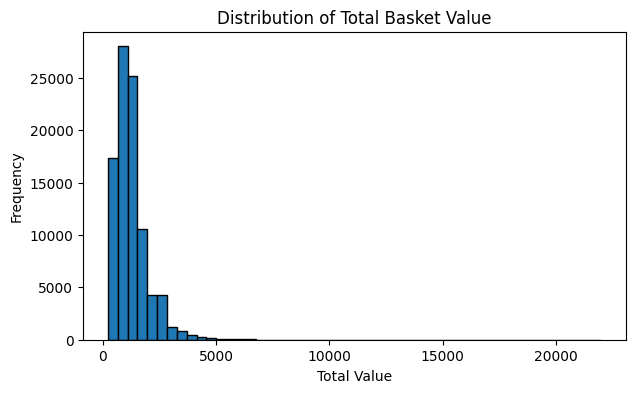

In [88]:
price_cols = [f'cash_price{i}' for i in range(1, 25)]
train_x_df['total_basket_value'] = train_x_df[price_cols].sum(axis=1, skipna=True)

plt.figure(figsize=(7, 4))
plt.hist(train_x_df['total_basket_value'].dropna(), bins=50, edgecolor='black')
plt.title('Distribution of Total Basket Value')
plt.xlabel('Total Value')
plt.ylabel('Frequency')
plt.show()

In [89]:
print(f"Max total basket value: {train_x_df['total_basket_value'].max()}")

Max total basket value: 21995.0


**Observation:** Most Total Basket Values seem to fall between 0 to around 3000. Some outliers of up to 21k

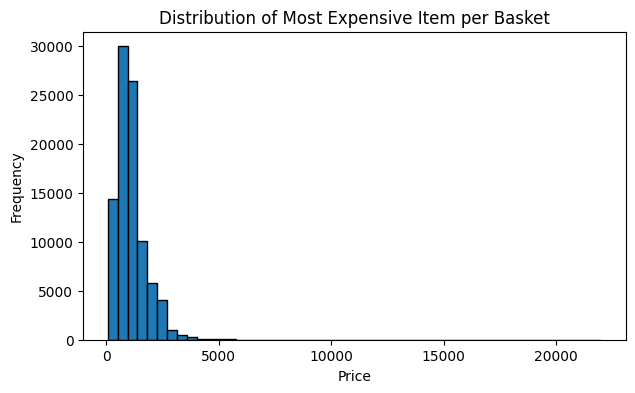

In [90]:
train_x_df['max_item_price'] = train_x_df[price_cols].max(axis=1, skipna=True)

plt.figure(figsize=(7, 4))
plt.hist(train_x_df['max_item_price'].dropna(), bins=50, edgecolor='black')
plt.title('Distribution of Most Expensive Item per Basket')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

**Observation:** Also concentrates between 0-3000 which makes sense.

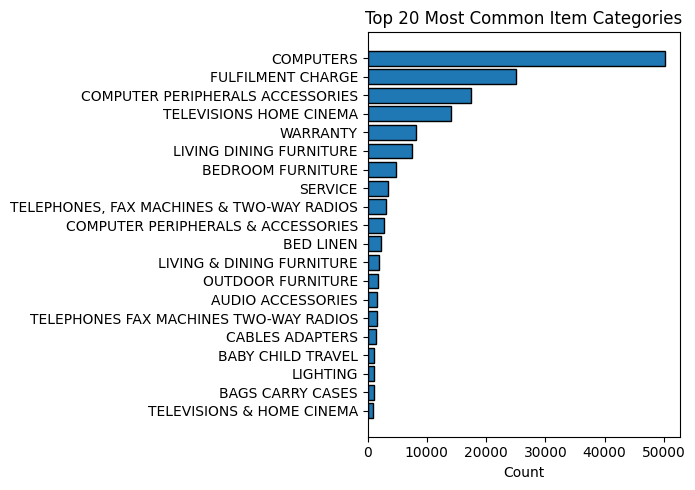

In [91]:
item_cols = [f'item{i}' for i in range(1, 25)]
item_counts = pd.Series(train_x_df[item_cols].values.flatten()).dropna().value_counts().head(20)

plt.figure(figsize=(7, 5))
plt.barh(item_counts.index[::-1], item_counts.values[::-1], edgecolor='black')
plt.title('Top 20 Most Common Item Categories')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

In [92]:
item_cols = [f'item{i}' for i in range(1, 25)]
all_items = pd.Series(train_x_df[item_cols].values.flatten()).dropna()

print(f"Total unique item categories: {all_items.nunique()}")
print(all_items.value_counts())

Total unique item categories: 173
COMPUTERS                           50221
FULFILMENT CHARGE                   25023
COMPUTER PERIPHERALS ACCESSORIES    17418
TELEVISIONS HOME CINEMA             14051
WARRANTY                             8213
                                    ...  
BLANK MEDIA & MEDIA STORAGE             1
PRODUCT                                 1
TECHNOLOGY ACCESSORIES                  1
HOME SAFETY EQUIPMENT                   1
HEALTH BEAUTY ACCESSORIES               1
Name: count, Length: 173, dtype: int64


**Observation:** There are 173 different item categories, however, the top 8 heavily dominate. Most sales are in the Computer Category.

In [100]:
train_x_df.describe()

,ID,cash_price1,cash_price2,cash_price3,cash_price4,cash_price5,cash_price6,cash_price7,cash_price8,cash_price9,...,Nbr_of_prod_purchas19,Nbr_of_prod_purchas20,Nbr_of_prod_purchas21,Nbr_of_prod_purchas22,Nbr_of_prod_purchas23,Nbr_of_prod_purchas24,Nb_of_items,total_basket_value,max_item_price,fraud_flag
count,92790.000000,92790.000000,44656.000000,12901.000000,4562.000000,2170.00000,1336.000000,946.000000,727.000000,568.000000,...,103.000000,91.000000,77.000000,63.000000,50.000000,43.000000,92790.000000,92790.000000,92790.000000,92790.000000
mean,57968.969070,1093.907124,191.608071,193.334548,176.132398,195.73871,162.015719,144.598309,130.957359,132.609155,...,1.388350,1.329670,1.220779,1.380952,1.160000,1.372093,1.764479,1234.759554,1140.466494,0.014215
std,33487.595782,711.172270,392.665621,375.676640,321.354938,374.22739,292.077355,291.432858,257.730692,267.234057,...,1.165122,0.869929,0.528737,0.923328,0.548095,1.113195,1.462264,771.484197,693.602559,0.118376
min,0.000000,2.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,219.000000,79.000000,0.000000
25%,28901.250000,649.000000,7.000000,7.000000,10.000000,16.00000,15.000000,20.000000,16.000000,18.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,779.000000,719.000000,0.000000
50%,57961.500000,949.000000,40.000000,43.000000,48.000000,59.00000,50.000000,50.000000,45.000000,45.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1099.000000,999.000000,0.000000
75%,86985.750000,1349.000000,139.000000,189.000000,189.000000,199.00000,179.250000,140.000000,120.000000,129.250000,...,1.000000,1.000000,1.000000,1.500000,1.000000,1.000000,2.000000,1499.000000,1379.000000,0.000000
max,115985.000000,21995.000000,6499.000000,5999.000000,5198.000000,4249.00000,2997.000000,4198.000000,2999.000000,2399.000000,...,7.000000,7.000000,4.000000,7.000000,4.000000,8.000000,60.000000,21995.000000,21995.000000,1.000000


### For Fraud Cases only:

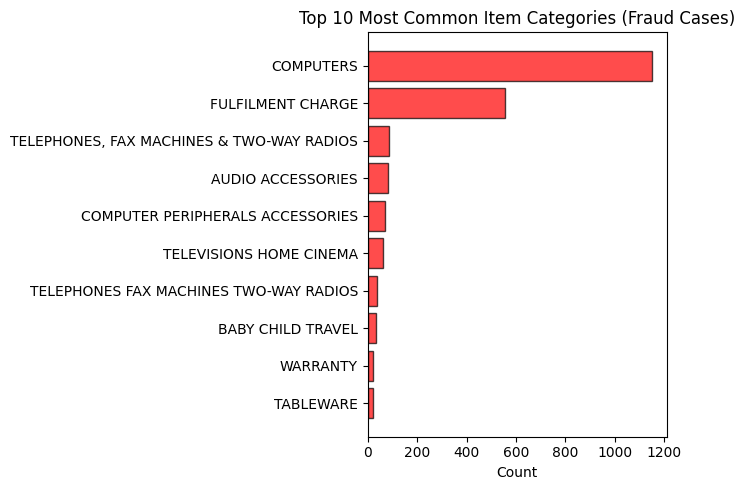

In [93]:
train_x_df['fraud_flag'] = train_y_df['fraud_flag'].values
fraud_df = train_x_df[train_x_df['fraud_flag'] == 1]

item_cols = [f'item{i}' for i in range(1, 25)]
fraud_items = pd.Series(fraud_df[item_cols].values.flatten()).dropna().value_counts().head(10)

plt.figure(figsize=(7, 5))
plt.barh(fraud_items.index[::-1], fraud_items.values[::-1], edgecolor='black', color='red', alpha=0.7)
plt.title('Top 10 Most Common Item Categories (Fraud Cases)')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

**Observation:** Computers and other tech accessories are the most common fraud items.

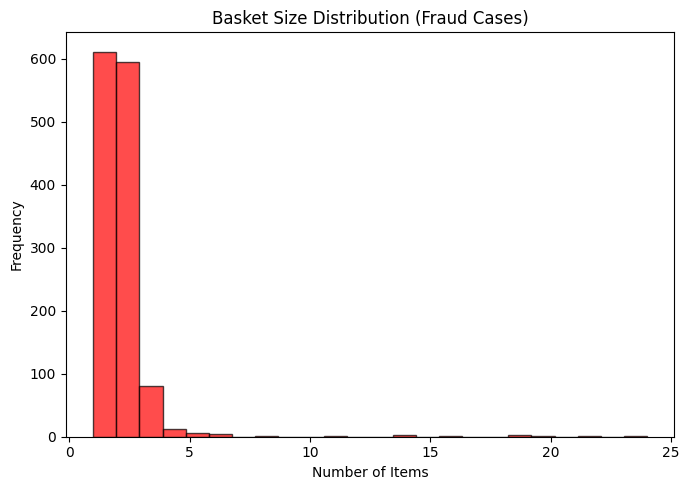

In [94]:
plt.figure(figsize=(7, 5))
plt.hist(fraud_df['Nb_of_items'].dropna(), bins=24, edgecolor='black', color='red', alpha=0.7)
plt.title('Basket Size Distribution (Fraud Cases)')
plt.xlabel('Number of Items')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Observation:** Mostly 1-3 items

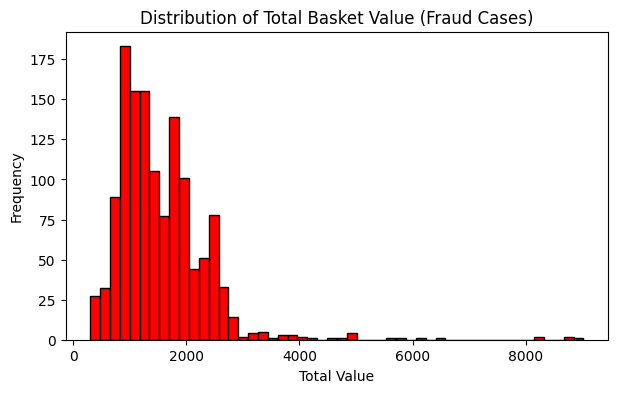

In [95]:
price_cols = [f'cash_price{i}' for i in range(1, 25)]
fraud_df['total_basket_value'] = fraud_df[price_cols].sum(axis=1, skipna=True)

plt.figure(figsize=(7, 4))
plt.hist(fraud_df['total_basket_value'].dropna(), bins=50, color='red', edgecolor='black')
plt.title('Distribution of Total Basket Value (Fraud Cases)')
plt.xlabel('Total Value')
plt.ylabel('Frequency')
plt.show()

In [96]:
print(f"Max total basket value: {fraud_df['total_basket_value'].max()}")

Max total basket value: 9018.0


**Observation:** A few outliers (9000), however most are below 3000

## Possible Biases

[Investigate the dataset for any biases that could affect the model’s performance and fairness (e.g., class imbalance, historical biases).]


0 = not fraud, 1 = fraud

fraud_flag
0    91471
1     1319
Name: count, dtype: int64


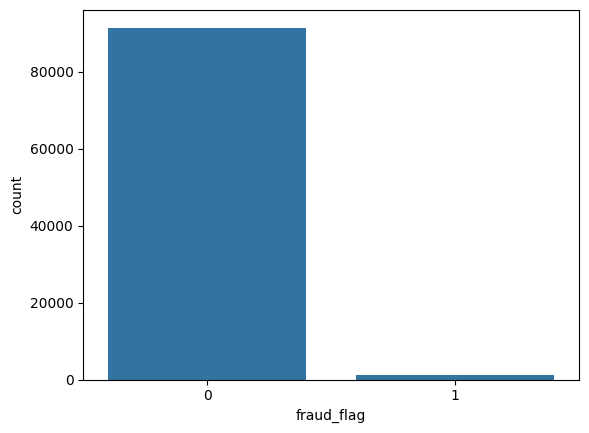

In [97]:
# Checking for class imbalance in a classification problem
sns.countplot(x='fraud_flag', data=train_y_df)

# Numerical number of samples of each class
print("0 = not fraud, 1 = fraud\n")
class_counts = train_y_df['fraud_flag'].value_counts()
print(class_counts)




Observation: as with most fraud detection tasks, the dataset is heavily imbalanced. There are way more samples of non fraud cases. 

## Correlations

[Explore correlations between features and the target variable, as well as among features themselves.]


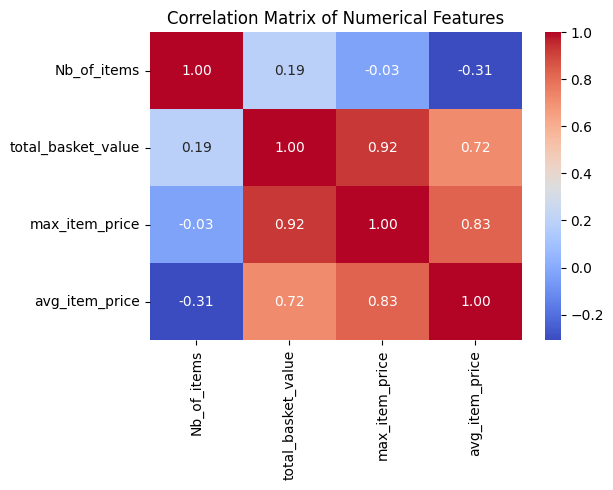

In [98]:
num_features = train_x_df[['Nb_of_items', 'total_basket_value', 'max_item_price']].copy()
num_features['avg_item_price'] = num_features['total_basket_value'] / num_features['Nb_of_items']

plt.figure(figsize=(6, 4))
sns.heatmap(num_features.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()


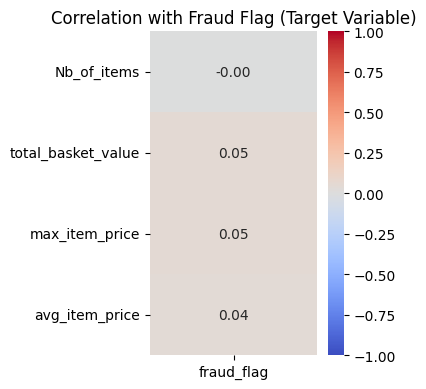

In [99]:
num_features['fraud_flag'] = train_y_df['fraud_flag'].values

correlations = num_features.corr()[['fraud_flag']].drop('fraud_flag')

plt.figure(figsize=(4, 4))
sns.heatmap(correlations, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation with Fraud Flag (Target Variable)')
plt.tight_layout()
plt.show()